# F1 AI Strategy Simulator

## Step 5 — Pit Stop Prediction Model

In this notebook we train a machine learning model that predicts the probability
that a driver will pit on the next lap.

Pit stop decisions depend on several factors:

- tire age
- laps since last pit
- pace degradation
- race position
- race gap to other cars
- tire compound

The model predicts:

P(pit_next_lap)

This probability will later be used inside the race simulator to determine
when drivers decide to pit.

In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

## Load Feature Dataset

We load the feature dataset created in Step 2.

In [2]:
df = pd.read_csv("../data/feature_dataset.csv")

print("Rows:", len(df))
df.head()

Rows: 145913


,DriverEncoded,TeamEncoded,TrackEncoded,Season,RegulationEra,LapNumber,lap_progress,Position,CompoundEncoded,tyre_age,...,WindSpeed,race_time,gap_ahead,gap_behind,traffic_pressure,drs_available,driver_pace_baseline,track_pace_baseline,pace_relative,LapTimeSeconds
0,6,9,0,2019,0,4.0,0.072727,1.0,1.0,7.0,...,2.553435,403.528,NaN,-1.595,NaN,0,100.640170,102.618405,0.148830,100.789
1,36,13,0,2019,0,4.0,0.072727,2.0,1.0,7.0,...,2.553435,405.123,1.595,-1.638,3.233,0,100.696642,102.618405,0.314358,101.011
2,15,9,0,2019,0,4.0,0.072727,3.0,1.0,7.0,...,2.553435,406.761,1.638,-3.923,5.561,0,100.665093,102.618405,0.565907,101.231
3,21,5,0,2019,0,4.0,0.072727,4.0,1.0,7.0,...,2.553435,410.684,3.923,-3.779,7.702,0,101.548231,102.618405,-0.044231,101.504
4,25,8,0,2019,0,4.0,0.072727,5.0,0.0,7.0,...,2.553435,414.463,3.779,-0.871,4.650,0,102.327385,102.618405,-0.016385,102.311


## Load Race Dataset

The race dataset contains the original telemetry data including pit stop timing.
We use this dataset to construct the pit stop target variable.

In [3]:
race_df = pd.read_csv("../data/race_dataset.csv")

race_df.head()

,Driver,Team,LapNumber,LapTime,Compound,TyreLife,Stint,Position,TrackStatus,PitInTime,...,Humidity,WindSpeed,LapTimeSeconds,Sector1Seconds,Sector2Seconds,Sector3Seconds,Season,Track,RegulationEra,IsPitLap
0,VER,Red Bull Racing,1.0,0 days 00:01:59.392000,INTERMEDIATE,1.0,1.0,2.0,124,NaN,...,78.421348,3.475281,119.392,NaN,20.705,55.250,2025,Melbourne,1,0
1,VER,Red Bull Racing,7.0,0 days 00:02:16.447000,INTERMEDIATE,7.0,4.0,2.0,41,NaN,...,78.421348,3.475281,136.447,45.898,29.735,60.814,2025,Melbourne,1,0
2,VER,Red Bull Racing,8.0,0 days 00:01:36.830000,INTERMEDIATE,8.0,4.0,2.0,1,NaN,...,78.421348,3.475281,96.830,35.249,20.145,41.436,2025,Melbourne,1,0
3,VER,Red Bull Racing,9.0,0 days 00:01:34.315000,INTERMEDIATE,9.0,4.0,2.0,1,NaN,...,78.421348,3.475281,94.315,33.850,19.608,40.857,2025,Melbourne,1,0
4,VER,Red Bull Racing,10.0,0 days 00:01:32.650000,INTERMEDIATE,10.0,4.0,2.0,1,NaN,...,78.421348,3.475281,92.650,33.117,19.414,40.119,2025,Melbourne,1,0


## Detect pit stop events

In [4]:
race_df["pit_event"] = race_df["PitInTime"].notnull().astype(int)

## Predict pit stop on next lap

In [5]:
race_df = race_df.sort_values(["Season","Track","Driver","LapNumber"])

race_df["pit_next_lap"] = (
    race_df.groupby(["Season","Track","Driver"])["pit_event"]
    .shift(-1)
)

race_df["pit_next_lap"] = race_df["pit_next_lap"].fillna(0)

## Merge Race Data with Feature Dataset

We merge the pit stop labels into the feature dataset.

## Encode Driver

Drivers may have different pit stop tendencies depending on team strategy.

In [6]:
race_df["DriverEncoded"] = race_df["Driver"].astype("category").cat.codes
race_df["TrackEncoded"] = race_df["Track"].astype("category").cat.codes

In [7]:
race_df = race_df[
    ["Season","TrackEncoded","DriverEncoded","LapNumber","pit_next_lap"]
]

In [8]:
df = df.merge(
    race_df,
    on=["Season","TrackEncoded","DriverEncoded","LapNumber"],
    how="left"
)

In [9]:
df["pit_next_lap"] = df["pit_next_lap"].fillna(0)

In [10]:
df["compound_stint_age"] = df["CompoundEncoded"] * df["tyre_age"]

In [11]:
track_pit_rate = (
    df.groupby("TrackEncoded")["pit_next_lap"]
    .mean()
    .rename("track_pit_rate")
)

df = df.merge(track_pit_rate, on="TrackEncoded")

## Define Feature Matrix

We select the features that influence pit stop decisions.

In [12]:
df = df[df["LapNumber"] > 5]

In [13]:
df["pit_window_pressure"] = df["laps_since_pit"] / (df["laps_since_pit"] + 10)

In [14]:
df["pace_drop"] = df["pace_trend"] - df["driver_pace_baseline"]

In [15]:

df["stint_progress"] = df["laps_since_pit"] / (
    df.groupby(["Season","TrackEncoded","DriverEncoded"])["laps_since_pit"].transform("max")
)

df["stint_progress"] = df["stint_progress"].fillna(0)

df["undercut_pressure"] = (df["gap_ahead"] < 2).astype(int)

In [16]:
features = [
"DriverEncoded",
"TrackEncoded",
"Season",
"Position",
"CompoundEncoded",
"tyre_age",
"stint_number",
"laps_since_pit",
"stint_progress",
"pace_trend",
"pace_drop",
"fuel_load",
"track_evolution",
"gap_ahead",
"gap_behind",
"traffic_pressure",
"undercut_pressure",
"compound_stint_age",
"track_pit_rate",
"pit_window_pressure"
]
X = df[features]

y = df["pit_next_lap"]

## Train / Test Split

We split the dataset into training and testing sets.

In [17]:
train_df = df[df["Season"] <= 2023]
test_df = df[df["Season"] >= 2024]

X_train = train_df[features]
y_train = train_df["pit_next_lap"]

X_test = test_df[features]
y_test = test_df["pit_next_lap"]

In [18]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

print("Class imbalance ratio:", ratio)

Class imbalance ratio: 33.85143442622951


## Train Pit Stop Prediction Model

Pit stops are relatively rare events, so we apply class weighting.

In [19]:
model = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=ratio,
    reg_lambda=1.2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.85
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Evaluate Model Performance

We evaluate the model using:

- Accuracy
- ROC-AUC score

In [20]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

probabilities = model.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, probabilities)

print("Accuracy:", accuracy)
print("ROC-AUC:", roc)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.7933742869679684
ROC-AUC: 0.816391975455099

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.80      0.88     44241
         1.0       0.09      0.67      0.16      1339

    accuracy                           0.79     45580
   macro avg       0.54      0.73      0.52     45580
weighted avg       0.96      0.79      0.86     45580



## Feature Importance

We inspect which factors influence pit stop decisions.

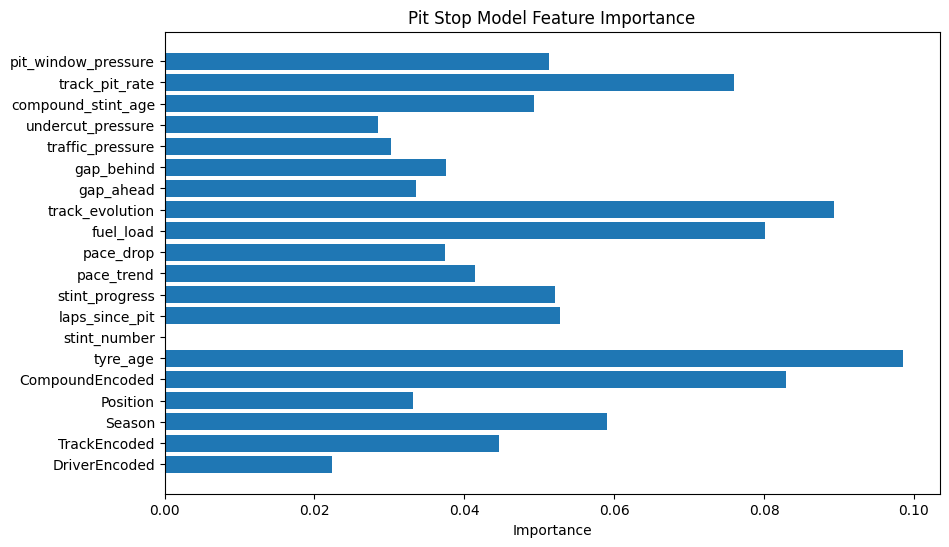

In [21]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))

plt.barh(feature_names, importance)

plt.title("Pit Stop Model Feature Importance")

plt.xlabel("Importance")

plt.show()

## Save Model

We save the trained model so the race simulator can load it later.

In [22]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/pit_stop_model.pkl")

print("Pit stop model saved successfully.")

Pit stop model saved successfully.
